In [52]:
import pandas as pd
import matplotlib.pyplot as plt

In [53]:
t1 = pd.read_excel("RunningTimeRecord.xlsx", sheet_name="Testing 1", skiprows=3)

t1.head()

,n,Computational Time (sec),Computational Time (sec).1,Speedup,Computational Time (sec).2,Speedup.1
0,10000000,1.981976,0.664019,2.984818,0.39406,5.02963
1,11000000,2.229783,0.760851,2.930643,0.444861,5.012314
2,12000000,2.526747,0.847935,2.979883,0.503745,5.015925
3,13000000,2.909777,0.93635,3.107574,0.56334,5.165223
4,14000000,3.193509,1.072575,2.977423,0.64324,4.964724


In [54]:
t1_8 = t1.iloc[0:31, [0,5]].copy()

t1_8

,n,Speedup.1
0,10000000,5.02963
1,11000000,5.012314
2,12000000,5.015925
3,13000000,5.165223
4,14000000,4.964724
5,15000000,4.909989
6,16000000,5.051774
7,17000000,4.975118
8,18000000,4.94328
9,19000000,5.087442


In [55]:
t1_32 = t1.iloc[35:66, [0,5]].copy()

t1_32

,n,Speedup.1
35,10000000,10.818895
36,11000000,14.233718
37,12000000,16.640132
38,13000000,17.288917
39,14000000,17.652806
40,15000000,16.005306
41,16000000,14.711933
42,17000000,14.198926
43,18000000,16.768739
44,19000000,17.35149


In [56]:
df1 = pd.merge(t1_8, t1_32, on='n')

df1.rename(
    columns={
        "Speedup.1_x": "speedup_8cores",
        "Speedup.1_y": "speedup_32cores"
    },
    inplace=True
)

df1

,n,speedup_8cores,speedup_32cores
0,10000000,5.02963,10.818895
1,11000000,5.012314,14.233718
2,12000000,5.015925,16.640132
3,13000000,5.165223,17.288917
4,14000000,4.964724,17.652806
5,15000000,4.909989,16.005306
6,16000000,5.051774,14.711933
7,17000000,4.975118,14.198926
8,18000000,4.94328,16.768739
9,19000000,5.087442,17.35149


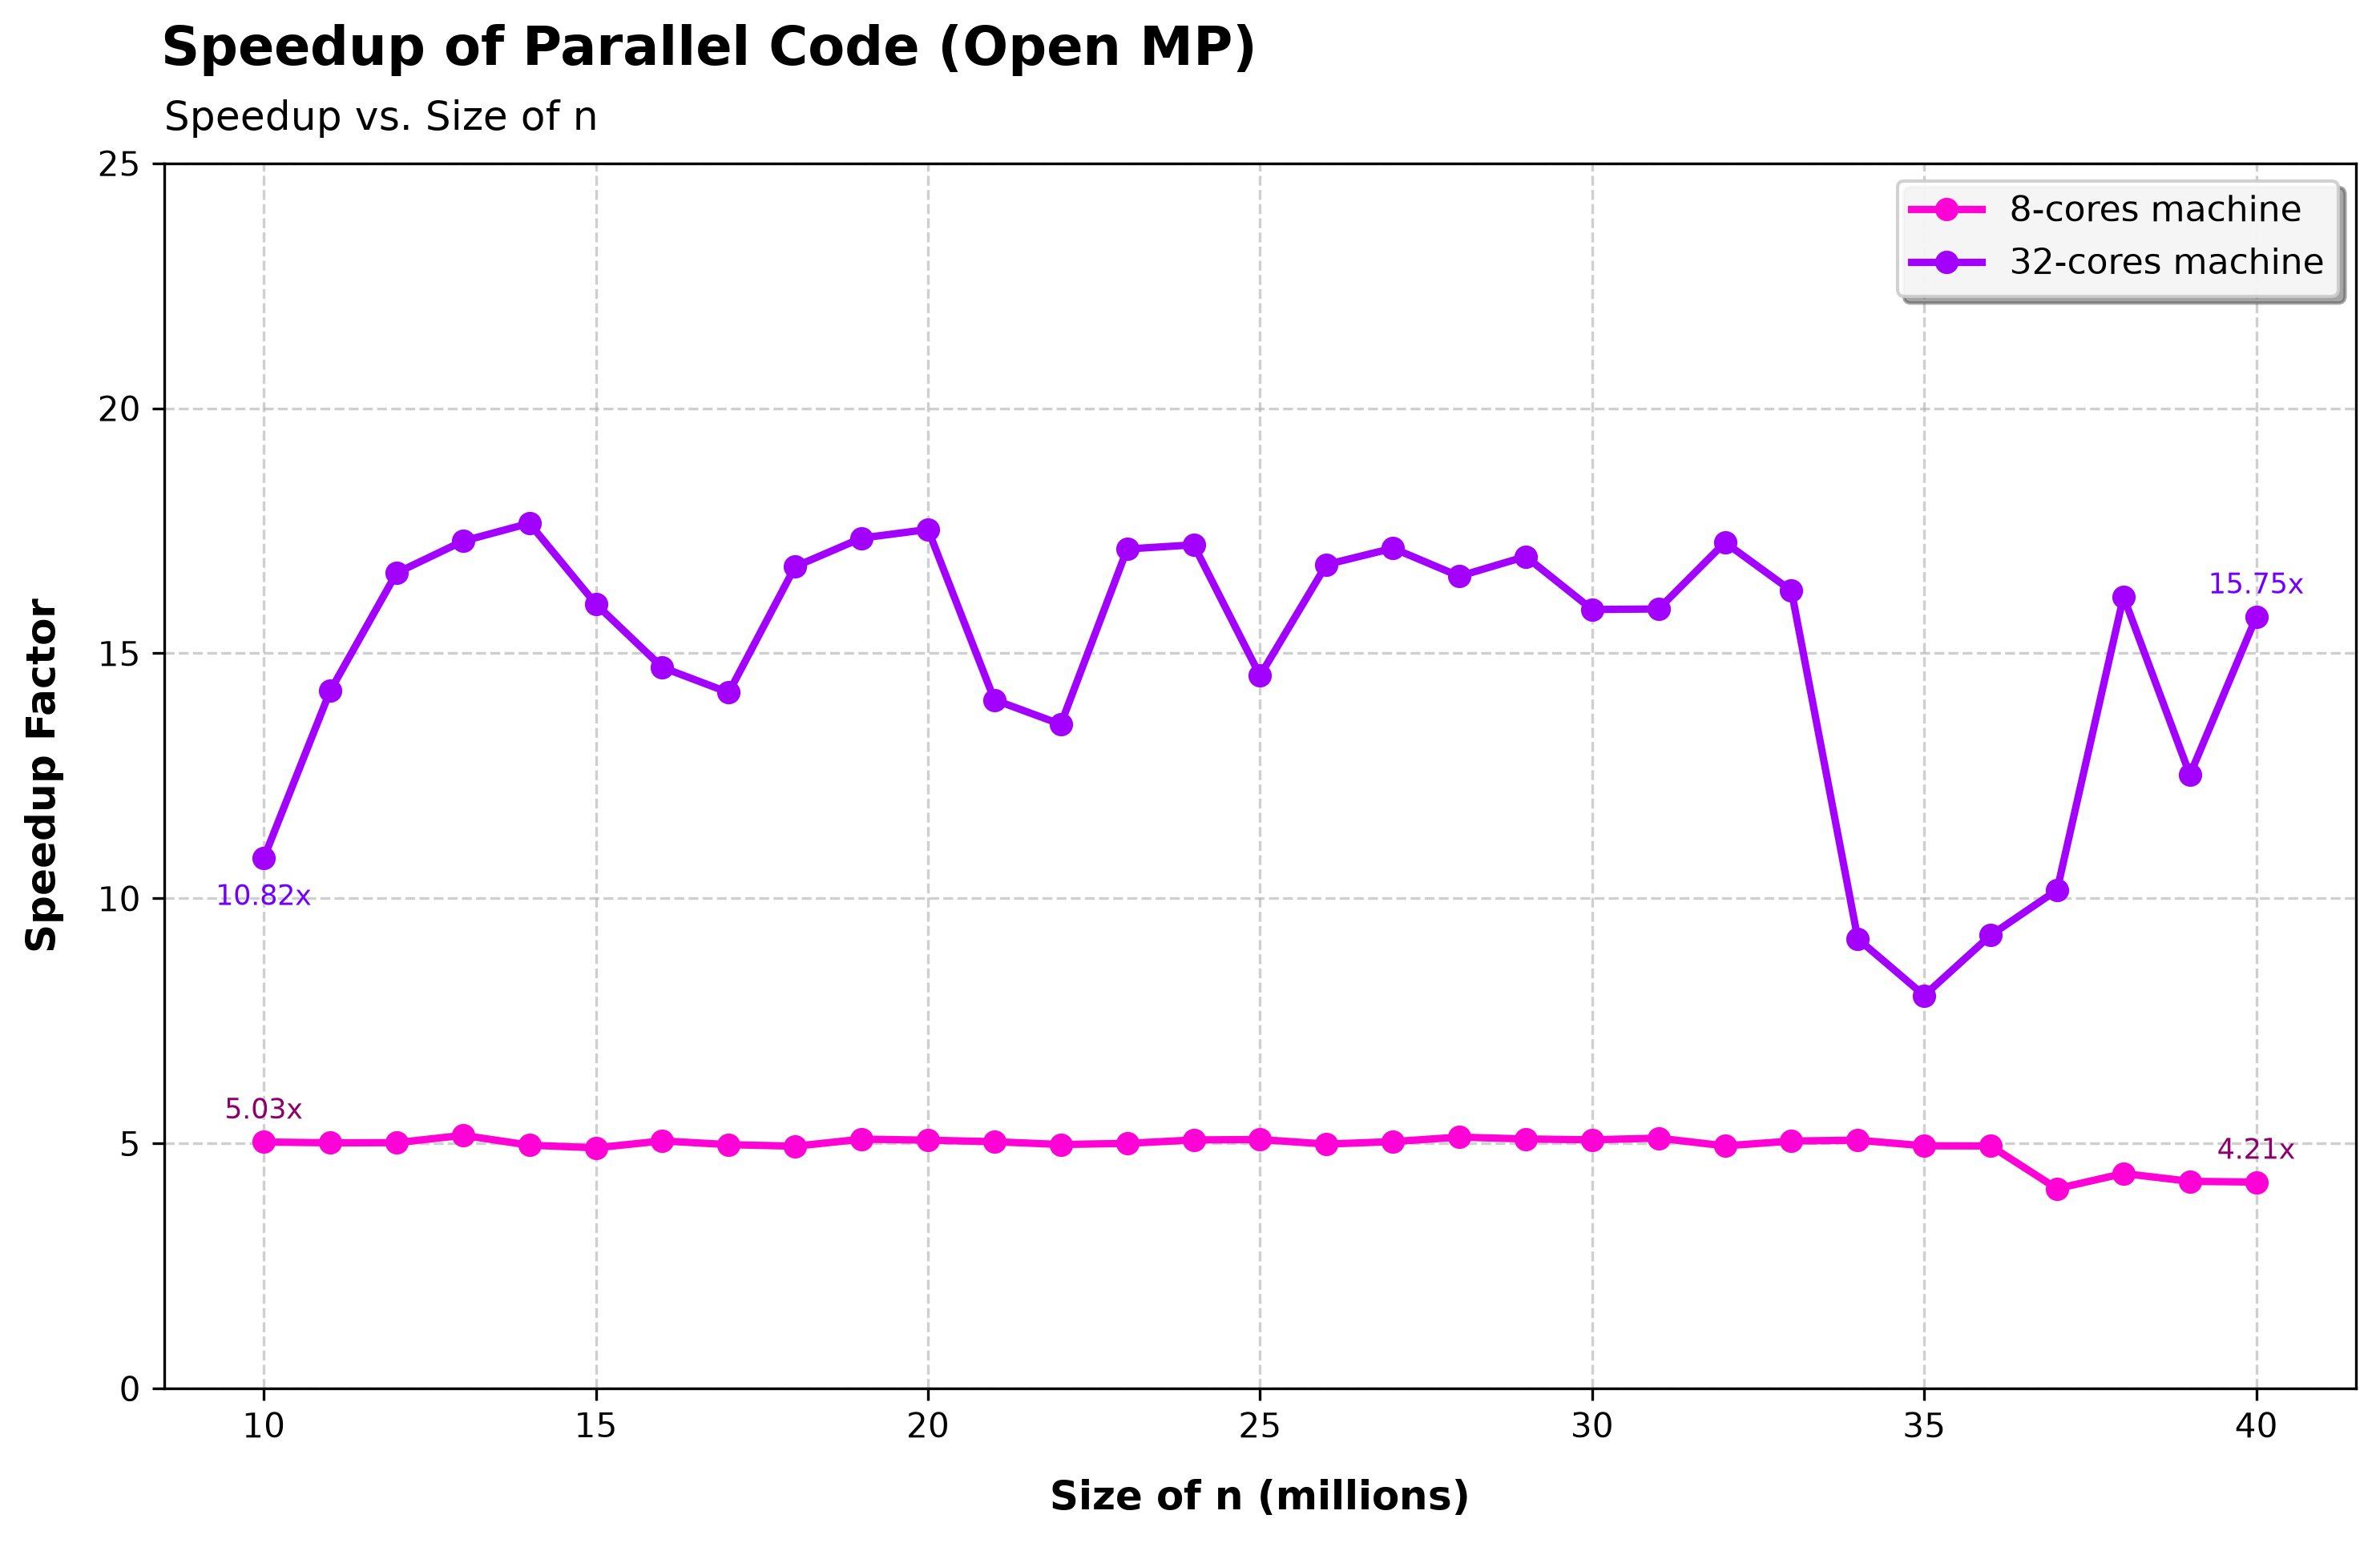

In [57]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter

# =============================================================
# Single Graph: Speedup vs. Size of n
# =============================================================
fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

# 8-core machine speedup
line1, = ax.plot(
    df1.n, df1.speedup_8cores,
    marker='o', markersize=6, linewidth=2.2,
    color="#FF02D5", label='8-cores machine'
)

# 32-core machine speedup
line2, = ax.plot(
    df1.n, df1.speedup_32cores,
    marker='o', markersize=6, linewidth=2.2,
    color="#A200FF", label='32-cores machine'
)

ax.set_title(
    "Speedup vs. Size of n",
    fontsize=12, loc='left', pad=10
)

ax.set_xlabel(
    "Size of n (millions)",
    fontsize=12, fontweight='semibold', labelpad=10
)

ax.set_ylabel(
    "Speedup Factor",
    fontsize=12, fontweight='semibold', labelpad=10
)

# X-axis: ticks every 5 million
ax.xaxis.set_major_locator(MultipleLocator(5_000_000))
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1_000_000:g}")
)

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(0, 25)

# =============================================================
# Annotations
# =============================================================

# 8-core first point
ax.annotate(
    f"{df1.speedup_8cores.iloc[0]:.2f}x",
    (df1.n.iloc[0], df1.speedup_8cores.iloc[0]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color="#8C016C"
)

# 8-core last point
ax.annotate(
    f"{df1.speedup_8cores.iloc[-1]:.2f}x",
    (df1.n.iloc[-1], df1.speedup_8cores.iloc[-1]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color="#8C016C"
)

# 32-core first point
ax.annotate(
    f"{df1.speedup_32cores.iloc[0]:.2f}x",
    (df1.n.iloc[0], df1.speedup_32cores.iloc[0]),
    textcoords='offset points',
    xytext=(0, -14),
    ha='center',
    fontsize=8.5,
    color="#7300FF"
)

# 32-core last point
ax.annotate(
    f"{df1.speedup_32cores.iloc[-1]:.2f}x",
    (df1.n.iloc[-1], df1.speedup_32cores.iloc[-1]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color="#7300FF"
)

# =============================================================
# Overall title
# =============================================================
fig.suptitle(
    "Speedup of Parallel Code (Open MP)",
    fontsize=16,
    fontweight='bold',
    x=0.072,
    y=0.91,
    ha='left'
)

# =============================================================
# Legend
# =============================================================
ax.legend(
    loc='upper right',
    fontsize=10.5,
    frameon=True,
    framealpha=0.9,
    shadow=True
)

plt.tight_layout(rect=[0, 0, 1, 0.94])

plt.savefig("task3_graph2.png", dpi=300)

plt.show()